In [4]:
# Core Data & Math Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Computer Vision & Image Processing
import cv2
import mediapipe as mp

# Video Processing
import decord  # Efficient video reader

# Deep Learning & ML Frameworks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import torch
import torch.nn as nn
import torchvision

# Scikit-learn Utilities
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Data Management & Utilities
import json
import pickle
import time
import os
from pathlib import Path
from collections import defaultdict, deque
import itertools

# Progress Tracking
from tqdm.auto import tqdm

# Statistical Analysis
from scipy.signal import savgol_filter, medfilt
from scipy.spatial import distance, transform


print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

# Initialize MediaPipe
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

print("MediaPipe initialized successfully!")

All libraries imported successfully!
TensorFlow version: 2.20.0
PyTorch version: 2.9.0+cpu
MediaPipe initialized successfully!


In [6]:
import yt_dlp
import os
import cv2
from pathlib import Path
import time
import json
from tqdm.auto import tqdm

class AggressiveMSASLDownloader:
    """Aggressive downloader that continues despite YouTube errors"""

    def __init__(self, data_path="C:/Users/suraa/Downloads/MS-ASL/MS-ASL",
                 download_dir="C:/Users/suraa/Downloads/MS-ASL/MS-ASL"):
        self.data_path = Path(data_path)
        self.download_dir = Path(download_dir)
        self.download_dir.mkdir(parents=True, exist_ok=True)

        # Subdirectories
        self.raw_videos_dir = self.download_dir / "raw_videos"
        self.processed_frames_dir = self.download_dir / "processed_frames"
        self.raw_videos_dir.mkdir(exist_ok=True)
        self.processed_frames_dir.mkdir(exist_ok=True)

        # Load dataset
        self.train_data, self.val_data, self.test_data, self.classes = self.load_dataset()

    def load_dataset(self):
        """Load MS-ASL dataset JSON files"""
        with open(self.data_path / "MSASL_train.json", 'r') as f:
            train_data = json.load(f)
        with open(self.data_path / "MSASL_val.json", 'r') as f:
            val_data = json.load(f)
        with open(self.data_path / "MSASL_test.json", 'r') as f:
            test_data = json.load(f)
        with open(self.data_path / "MSASL_classes.json", 'r') as f:
            classes = json.load(f)

        print(f"Loaded dataset: {len(train_data)} train, {len(val_data)} val, {len(test_data)} test samples")
        return train_data, val_data, test_data, classes

    def get_already_processed_videos(self):
        """Get list of videos that have already been processed"""
        processed_videos = set()
        
        if self.processed_frames_dir.exists():
            for video_dir in self.processed_frames_dir.glob("*"):
                frames = list(video_dir.glob("frame_*.jpg"))
                if frames:
                    processed_videos.add(video_dir.name)
        
        print(f"✅ Found {len(processed_videos)} already processed videos")
        return processed_videos

    def _download_single_video(self, url, video_id):
        """Download a single video - SILENT and AGGRESSIVE"""
        try:
            output_template = str(self.raw_videos_dir / f"{video_id}.%(ext)s")
            ydl_opts = {
                'format': 'best[height<=480]',
                'outtmpl': output_template,
                'quiet': True,  # SILENT MODE - no output
                'no_warnings': True,
                'ignoreerrors': True,  # IGNORE ALL ERRORS
                'noplaylist': True,
                'socket_timeout': 30,
                'retries': 3,
            }
            
            with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                # JUST DOWNLOAD - don't check availability first
                ydl.download([url])

            # Check if file was actually downloaded
            downloaded_files = list(self.raw_videos_dir.glob(f"{video_id}.*"))
            if downloaded_files:
                return downloaded_files[0]
            return None
            
        except Exception:
            # SILENTLY CATCH ALL ERRORS
            return None

    def _extract_frames_from_video(self, video_path, start_time, end_time, target_fps=5):
        """Extract frames safely"""
        try:
            cap = cv2.VideoCapture(str(video_path))
            if not cap.isOpened(): return []

            video_fps = cap.get(cv2.CAP_PROP_FPS)
            if video_fps <= 0: return []
            
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            start_frame = int(start_time * video_fps)
            end_frame = int(end_time * video_fps)
            start_frame = max(0, min(start_frame, total_frames-1))
            end_frame = max(start_frame+1, min(end_frame, total_frames))

            frames = []
            # Simple frame extraction - take every Nth frame
            for frame_idx in range(start_frame, end_frame, max(1, int(video_fps/target_fps))):
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                if ret:
                    frame = cv2.resize(frame, (224, 224))
                    frames.append(frame)
                if len(frames) >= 20:  # Reduced from 30 to be faster
                    break
            cap.release()
            return frames
        except Exception:
            return []

    def download_until_target(self, dataset_type="train", target_count=50):
        """Keep downloading until we reach target count, ignoring errors"""
        dataset = {
            'train': self.train_data,
            'val': self.val_data,
            'test': self.test_data
        }[dataset_type]

        # Get already processed videos
        processed_videos = self.get_already_processed_videos()
        current_count = len(processed_videos)
        
        print(f"🎯 Target: {target_count} total processed videos")
        print(f"📊 Current: {current_count} videos")
        print(f"📥 Need: {target_count - current_count} new videos")
        print("🚀 Starting AGGRESSIVE download (ignoring YouTube errors)...")

        successful_downloads = []
        total_attempted = 0
        
        pbar = tqdm(total=target_count - current_count, desc="Downloading new videos")

        # Start from where we left off
        start_index = current_count
        
        for i in range(start_index, len(dataset)):
            if len(successful_downloads) >= (target_count - current_count):
                break
                
            sample = dataset[i]
            total_attempted += 1

            try:
                video_id = f"{sample['signer_id']}_{i}_{sample['label']}_{sample['clean_text'].replace(' ', '_')}"

                # Skip if already processed
                if video_id in processed_videos:
                    continue

                # SILENT DOWNLOAD - no error messages
                video_path = self._download_single_video(sample['url'], video_id)
                
                if video_path:
                    # Extract frames
                    frames = self._extract_frames_from_video(video_path, sample['start_time'], sample['end_time'])
                    
                    if frames:
                        # Save frames
                        frame_dir = self.processed_frames_dir / video_id
                        frame_dir.mkdir(exist_ok=True)
                        for j, frame in enumerate(frames):
                            cv2.imwrite(str(frame_dir / f"frame_{j:04d}.jpg"), frame)

                        successful_downloads.append({
                            **sample,
                            'sample_id': video_id,
                            'frames_path': str(frame_dir),
                            'num_frames': len(frames)
                        })
                        pbar.update(1)
                        print(f" Success: {sample['clean_text']}")
                
                # Small delay to avoid being blocked
                time.sleep(0.5)
                
            except Exception:
                # SILENTLY CONTINUE ON ANY ERROR
                continue

        pbar.close()
        
        final_count = current_count + len(successful_downloads)
        
        print(f"\n=== FINAL RESULTS ===")
        print(f" Successfully downloaded: {len(successful_downloads)} new videos")
        print(f" Total processed videos: {final_count}")
        print(f" Target: {target_count}")
        print(f" Success rate: {len(successful_downloads)/total_attempted*100:.1f}%")
        
        if final_count < target_count:
            print(f"  Fell short by {target_count - final_count} videos")
            print(" Try running again or increase the dataset range")
        
        return successful_downloads

# RUN THE AGGRESSIVE DOWNLOADER
if __name__ == "__main__":
    downloader = AggressiveMSASLDownloader(download_dir="C:/Users/suraa/Downloads/MS-ASL/MS-ASL")
    
    # Download until we have 100 total processed videos
    successful = downloader.download_until_target(
        dataset_type="train", 
        target_count=100  # We have 48, so download 52 more
    )
    
    print(f"\n🎉 Download complete! You now have ~100 processed videos for training!")

Loaded dataset: 16054 train, 5287 val, 4172 test samples
✅ Found 50 already processed videos
🎯 Target: 100 total processed videos
📊 Current: 50 videos
📥 Need: 50 new videos
🚀 Starting AGGRESSIVE download (ignoring YouTube errors)...


 Success: wow                                                            
 Success: pass                                                           
                                                                         

ERROR: [WinError 5] Access is denied: 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\6_52_566_pass.temp.mp4' -> 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\6_52_566_pass.mp4'


 Success: pass
 Success: think                                                        


ERROR: [youtube] 0Beq_NIDj2c: Video unavailable
ERROR: [youtube] 0Beq_NIDj2c: Video unavailable


...

 Success: actor                                                            
 Success: actor                                                           
 Success: live                                                           
 Success: live                                                             
 Success: america                                                        
 Success: america                                                         
 Success: beach                                                          
 Success: beach                                                          
 Success: birthday                                                       
 Success: birthday                                                       
 Success: black                                                          
                                                                           

ERROR: [WinError 5] Access is denied: 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\12_179_41_black.temp.mp4' -> 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\12_179_41_black.mp4'


 Success: black
 Success: blue                                                           
 Success: blue                                                             
 Success: brown                                                          
                                                                         

ERROR: [WinError 5] Access is denied: 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\12_183_74_brown.temp.mp4' -> 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\12_183_74_brown.mp4'


 Success: brown
 Success: celebrate                                                      
 Success: celebrate                                                      
 Success: christmas                                                      
 Success: christmas                                                      

=== FINAL RESULTS ===
 Successfully downloaded: 50 new videos
 Total processed videos: 100
 Target: 100
 Success rate: 36.2%

🎉 Download complete! You now have ~100 processed videos for training!


In [3]:
import yt_dlp
import os
import cv2
from pathlib import Path
import time
import json
from tqdm.auto import tqdm

class MSASLBatchDownloader:
    """Robust batch downloader for MS-ASL videos"""

    def __init__(self, data_path="C:/Users/suraa/Downloads/MS-ASL/MS-ASL",
                 download_dir="C:/Users/suraa/Downloads/MS-ASL/MS-ASL"):
        self.data_path = Path(data_path)
        self.download_dir = Path(download_dir)
        self.download_dir.mkdir(parents=True, exist_ok=True)

        # Subdirectories
        self.raw_videos_dir = self.download_dir / "raw_videos"
        self.processed_frames_dir = self.download_dir / "processed_frames"
        self.raw_videos_dir.mkdir(exist_ok=True)
        self.processed_frames_dir.mkdir(exist_ok=True)

        # Load dataset
        self.train_data, self.val_data, self.test_data, self.classes = self.load_dataset()

    def load_dataset(self):
        """Load MS-ASL dataset JSON files"""
        with open(self.data_path / "MSASL_train.json", 'r') as f:
            train_data = json.load(f)
        with open(self.data_path / "MSASL_val.json", 'r') as f:
            val_data = json.load(f)
        with open(self.data_path / "MSASL_test.json", 'r') as f:
            test_data = json.load(f)
        with open(self.data_path / "MSASL_classes.json", 'r') as f:
            classes = json.load(f)

        print(f"Loaded dataset: {len(train_data)} train, {len(val_data)} val, {len(test_data)} test samples")
        return train_data, val_data, test_data, classes

    def _download_single_video(self, url, video_id, max_retries=3):
        """Download a single video with retry and format fallback"""
        for attempt in range(max_retries):
            try:
                output_template = str(self.raw_videos_dir / f"{video_id}.%(ext)s")
                ydl_opts = {
                    'format': 'bestvideo[height<=480]+bestaudio/best',
                    'outtmpl': output_template,
                    'quiet': True,
                    'no_warnings': True,
                    'ignoreerrors': True,
                    'noplaylist': True,
                    'socket_timeout': 30,
                    'retries': 3,
                    'continuedl': True,
                }
                with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                    info = ydl.extract_info(url, download=False)
                    if info is None:
                        print("  Could not fetch video info, skipping...")
                        return None
                    duration = info.get('duration', 0)
                    # Skip videos longer than 5 min
                    if duration > 300:
                        print(f"  Skipping long video ({duration}s)")
                        return None
                    ydl.download([url])

                downloaded_files = list(self.raw_videos_dir.glob(f"{video_id}.*"))
                if downloaded_files:
                    return downloaded_files[0]
            except Exception as e:
                if attempt < max_retries - 1:
                    time.sleep(2)
                else:
                    print(f"  Failed after {max_retries} attempts: {e}")
        return None

    def _extract_frames_from_video(self, video_path, start_time, end_time, target_fps=5):
        """Extract frames safely"""
        try:
            cap = cv2.VideoCapture(str(video_path))
            if not cap.isOpened(): return []

            video_fps = cap.get(cv2.CAP_PROP_FPS)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            start_frame = int(start_time * video_fps)
            end_frame = int(end_time * video_fps)
            start_frame = max(0, min(start_frame, total_frames-1))
            end_frame = max(start_frame+1, min(end_frame, total_frames))

            total_target_frames = int((end_time - start_time) * target_fps)
            frame_interval = max(1, (end_frame - start_frame)//total_target_frames)

            frames = []
            for fidx in range(start_frame, end_frame, frame_interval):
                cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
                ret, frame = cap.read()
                if ret:
                    frame = cv2.resize(frame, (224, 224))
                    frames.append(frame)
                if len(frames) >= 30:  # max frames per video
                    break
            cap.release()
            return frames
        except Exception as e:
            print(f"  Frame extraction error: {e}")
            return []

    def _save_progress(self, successful, failed, dataset_type):
        """Save progress to JSON"""
        progress_file = self.download_dir / f"download_progress_{dataset_type}.json"
        progress = {
            'successful': successful,
            'failed': [{'sample': f[0], 'error': f[1]} for f in failed],
            'timestamp': time.time(),
            'total_successful': len(successful),
            'total_failed': len(failed)
        }
        with open(progress_file, 'w') as f:
            json.dump(progress, f, indent=2)

    def download_exactly_50(self, dataset_type="train"):
        """Download exactly 50 videos, skipping failed or long videos"""
        dataset = {
            'train': self.train_data,
            'val': self.val_data,
            'test': self.test_data
        }[dataset_type]

        print(f"Downloading exactly 50 videos from {dataset_type} set...")
        successful_downloads, failed_downloads = [], []
        pbar = tqdm(total=50, desc=f"Downloading {dataset_type}")

        i = 0  # dataset index
        while len(successful_downloads) < 50 and i < len(dataset):
            sample = dataset[i]
            i += 1

            try:
                video_id = f"{sample['signer_id']}_{i}_{sample['label']}_{sample['clean_text'].replace(' ', '_')}"

                # Skip if already downloaded
                if list(self.processed_frames_dir.glob(f"{video_id}_*")):
                    successful_downloads.append(sample)
                    pbar.update(1)
                    continue

                # Download video
                video_path = self._download_single_video(sample['url'], video_id)
                if not video_path:
                    failed_downloads.append((sample, "Download failed or skipped"))
                    continue

                # Extract frames
                frames = self._extract_frames_from_video(video_path, sample['start_time'], sample['end_time'])
                if not frames:
                    failed_downloads.append((sample, "No frames extracted"))
                    continue

                # Save frames
                frame_dir = self.processed_frames_dir / video_id
                frame_dir.mkdir(exist_ok=True)
                for j, frame in enumerate(frames):
                    cv2.imwrite(str(frame_dir / f"frame_{j:04d}.jpg"), frame)

                successful_downloads.append({
                    **sample,
                    'sample_id': video_id,
                    'frames_path': str(frame_dir),
                    'num_frames': len(frames)
                })
                pbar.update(1)

            except Exception as e:
                failed_downloads.append((sample, str(e)))

        pbar.close()
        self._save_progress(successful_downloads, failed_downloads, dataset_type)
        print(f"Download complete: {len(successful_downloads)} success, {len(failed_downloads)} failed")
        print(f"Check folder: {self.download_dir}")
        return successful_downloads, failed_downloads

if __name__ == "__main__":
    downloader = MSASLBatchDownloader(download_dir="C:/Users/suraa/Downloads/MS-ASL/MS-ASL")
    successful, failed = downloader.download_exactly_50(dataset_type="train")

    print(f"\n Successfully downloaded {len(successful)} videos.")
    print(f"Failed downloads: {len(failed)}")

Loaded dataset: 16054 train, 5287 val, 4172 test samples


ERROR: [youtube] 9FdHlMOnVjg: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


  Could not fetch video info, skipping...
                                                           

ERROR: [youtube] 1AyT77LqJzQ: Video unavailable


  Could not fetch video info, skipping...


...

  Could not fetch video info, skipping...
                                                           

ERROR: [youtube] 25BrmaKbzYo: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


  Could not fetch video info, skipping...
                                                                        

ERROR: [WinError 5] Access is denied: 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\8_74_56_drink.temp.mp4' -> 'C:\\Users\\suraa\\Downloads\\MS-ASL\\MS-ASL\\raw_videos\\8_74_56_drink.mp4'


Download complete: 50 success, 33 failed                   
Check folder: C:\Users\suraa\Downloads\MS-ASL\MS-ASL

🎉 Successfully downloaded 50 videos.
Failed downloads: 33


In [11]:
# Define directories
dataset_dir = Path(r"C:\Users\suraa\Downloads\MS-ASL\MS-ASL\raw_videos")
output_dir = Path(r"C:\Users\suraa\Downloads\MS-ASL\MS-ASL\landmarks")
output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
# landmark_extractor.py
class LandmarkExtractor:    
    def __init__(self, static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5):
        self.hands = mp.solutions.hands.Hands(
            static_image_mode=static_image_mode,
            max_num_hands=max_num_hands,
            min_detection_confidence=min_detection_confidence,
            min_tracking_confidence=0.5
        )
        
    def extract_landmarks_from_frame(self, frame):
        """Extract REAL hand landmarks from a single frame - return empty if no hands"""
        try:
            # Convert BGR to RGB
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image_rgb.flags.writeable = False
            
            # Process with MediaPipe
            results = self.hands.process(image_rgb)
            
            image_rgb.flags.writeable = True
            
            landmarks_list = []
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    # Extract all 21 landmarks with x, y, z coordinates
                    landmarks = []
                    for landmark in hand_landmarks.landmark:
                        landmarks.append([landmark.x, landmark.y, landmark.z])
                    landmarks_list.append(np.array(landmarks))
            
            return landmarks_list  # Returns empty list if no hands detected
            
        except Exception as e:
            print(f"Error in landmark extraction: {e}")
            return []  # Return empty
    
    def extract_landmarks_from_video(self, frames_directory):
        """Extract REAL landmarks from all frames in a directory"""
        frame_dir = Path(frames_directory)
        if not frame_dir.exists():
            print(f"Directory not found: {frames_directory}")
            return []
        
        # Get all frame files sorted
        frame_files = sorted(frame_dir.glob("frame_*.jpg"))
        if not frame_files:
            print(f"No frame files found in: {frames_directory}")
            return []
        
        all_landmarks = []
        frames_with_landmarks = 0
        
        print(f"Processing {len(frame_files)} frames from {frame_dir.name}")
        
        for frame_file in tqdm(frame_files, desc=f"Extracting landmarks", leave=False):
            try:
                # Read frame
                frame = cv2.imread(str(frame_file))
                if frame is None:
                    print(f"Could not read frame: {frame_file}")
                    continue
                frame_landmarks = self.extract_landmarks_from_frame(frame)
                
                if frame_landmarks:
                    # Take the first hand detected
                    all_landmarks.append(frame_landmarks[0])
                    frames_with_landmarks += 1
                       
            except Exception as e:
                print(f"Error processing {frame_file}: {e}")
    
        
        print(f"Successfully extracted landmarks from {frames_with_landmarks}/{len(frame_files)} frames")
        
        return all_landmarks

    def extract_landmarks_from_all_videos(self, base_directory):
        """Extract REAL landmarks from all video directories"""
        base_dir = Path(base_directory)
        processed_frames_dir = base_dir / "processed_frames"
        
        if not processed_frames_dir.exists():
            print(f"Processed frames directory not found: {processed_frames_dir}")
            return {}
        
        # Find all video directories
        video_dirs = list(processed_frames_dir.glob("*"))
        print(f"Found {len(video_dirs)} video directories")
        
        all_landmarks_data = {}
        
        for video_dir in tqdm(video_dirs, desc="Processing all videos"):
            try:
                # Parse video info from directory name
                parts = video_dir.name.split('_')
                if len(parts) >= 4:
                    label = int(parts[2])
                    text = '_'.join(parts[3:]).replace('_', ' ')
                else:
                    label = 0
                    text = 'unknown'

                landmarks = self.extract_landmarks_from_video(video_dir)
                
                all_landmarks_data[video_dir.name] = {
                    'landmarks': landmarks, 
                    'num_frames': len(list(video_dir.glob("frame_*.jpg"))),
                    'num_landmark_frames': len(landmarks),
                    'label': label,
                    'text': text
                }
                
            except Exception as e:
                print(f"Error processing {video_dir.name}: {e}")
    
        
        return all_landmarks_data

    def save_landmarks(self, landmarks_data, output_file="real_landmarks.json"):
        """Save REAL landmarks data to JSON file"""
        # Convert numpy arrays to lists for JSON serialization
        serializable_data = {}
        for video_id, data in landmarks_data.items():
            # Only save if we have real landmarks
            if data['landmarks']:
                serializable_data[video_id] = {
                    'landmarks': [lm.tolist() for lm in data['landmarks']],
                    'num_frames': data['num_frames'],
                    'num_landmark_frames': data['num_landmark_frames'],
                    'label': data['label'],
                    'text': data['text']
                }
        
        with open(output_file, 'w') as f:
            json.dump(serializable_data, f, indent=2)
        
        print(f"Real landmarks saved to: {output_file}")
        print(f"Saved {len(serializable_data)} videos with real landmarks")
        return output_file

def extract_real_landmarks(base_directory="C:/Users/suraa/Downloads/MS-ASL/MS-ASL"):
    print("EXTRACTING LANDMARKS FROM ALL VIDEOS")
    
    extractor = LandmarkExtractor()
    landmarks_data = extractor.extract_landmarks_from_all_videos(base_directory)
    
    # Filter out videos with no landmarks
    videos_with_landmarks = {k: v for k, v in landmarks_data.items() if v['landmarks']}
    
    # Print summary
    total_videos = len(landmarks_data)
    successful_videos = len(videos_with_landmarks)
    total_frames = sum(data['num_frames'] for data in landmarks_data.values())
    total_landmark_frames = sum(data['num_landmark_frames'] for data in landmarks_data.values())
    
    print(f"Total videos processed: {total_videos}")
    print(f"Videos with REAL landmarks: {successful_videos}")
    print(f"Total frames analyzed: {total_frames}")
    print(f"Frames with REAL landmarks: {total_landmark_frames}")
    print(f"Success rate: {total_landmark_frames/total_frames*100:.1f}%" if total_frames > 0 else "Success rate: 0%")
    
    if successful_videos == 0:
        print("❌ NO LANDMARKS EXTRACTED! Check if videos were downloaded properly.")
        return {}
    
    # Save only real landmarks
    output_file = extractor.save_landmarks(videos_with_landmarks)
    
    return videos_with_landmarks

if __name__ == "__main__":
    real_landmarks = extract_real_landmarks()

EXTRACTING LANDMARKS FROM ALL VIDEOS
Found 100 video directories


Processing all videos:   0%|          | 0/100 [00:00<?, ?it/s]

Processing 16 frames from 0_111_400_wait


Extracting landmarks:   0%|          | 0/16 [00:00<?, ?it/s]

Successfully extracted landmarks from 11/16 frames
Processing 16 frames from 0_118_962_any


...

Successfully extracted landmarks from 10/11 frames
Processing 13 frames from 8_82_914_down


Extracting landmarks:   0%|          | 0/13 [00:00<?, ?it/s]

Successfully extracted landmarks from 10/13 frames
Processing 13 frames from 8_83_76_hurt


Extracting landmarks:   0%|          | 0/13 [00:00<?, ?it/s]

Successfully extracted landmarks from 12/13 frames
Total videos processed: 100
Videos with REAL landmarks: 97
Total frames analyzed: 1552
Frames with REAL landmarks: 979
Success rate: 63.1%
Real landmarks saved to: real_landmarks.json
Saved 97 videos with real landmarks


In [6]:
class FeatureExtractor:
    
    @staticmethod
    def extract_all_features(landmarks_sequence):
        if not landmarks_sequence or len(landmarks_sequence) == 0:
            return {}  # Return empty
        
        features = {}
        
        try:
            # Convert to numpy array
            landmarks_seq = np.array(landmarks_sequence)
            
            # 1. Static pose features (from mean landmarks)
            mean_landmarks = np.mean(landmarks_seq, axis=0)
            features.update(FeatureExtractor.extract_static_pose_features(mean_landmarks))
            
            # 2. Dynamic motion features
            features.update(FeatureExtractor.extract_dynamic_motion_features(landmarks_seq))
            
            # 3. Hand shape features
            features.update(FeatureExtractor.extract_hand_shape_features(mean_landmarks))
            
            # 4. Finger-specific features
            features.update(FeatureExtractor.extract_finger_features(mean_landmarks))
            
            # 5. Temporal features
            features.update(FeatureExtractor.extract_temporal_features(landmarks_seq))
            
        except Exception as e:
            print(f"Error in feature extraction: {e}")
            return {}  # Return empty on error
        
        return features
    
    @staticmethod
    def extract_static_pose_features(landmarks):
        """Extract static hand pose features"""
        features = {}
        
        # Finger joint angles (15 features)
        features['finger_angles'] = FeatureExtractor.calculate_finger_angles(landmarks)
        
        # Hand distances (20 features)
        features['hand_distances'] = FeatureExtractor.calculate_hand_distances(landmarks)
        
        # Palm orientation
        features['palm_orientation'] = FeatureExtractor.calculate_palm_orientation(landmarks)
        
        # Wrist position relative to hand
        features['wrist_position'] = landmarks[0].tolist()  # Landmark 0 is wrist
        
        return features
    
    @staticmethod
    def extract_dynamic_motion_features(landmarks_seq):
        """Extract dynamic motion features from sequence"""
        features = {}
        
        if len(landmarks_seq) < 2:
            return features  # Return empty if insufficient frames
        
        # Wrist motion analysis
        wrist_positions = landmarks_seq[:, 0, :]  # Landmark 0 is wrist
        
        # Velocity (first derivative)
        velocity = np.diff(wrist_positions, axis=0)
        features['wrist_velocity_mean'] = np.mean(velocity, axis=0).tolist()
        features['wrist_velocity_std'] = np.std(velocity, axis=0).tolist()
        features['wrist_velocity_max'] = float(np.max(np.linalg.norm(velocity, axis=1)))
        
        # Acceleration (second derivative)
        if len(velocity) > 1:
            acceleration = np.diff(velocity, axis=0)
            features['wrist_acceleration_mean'] = np.mean(acceleration, axis=0).tolist()
            features['wrist_acceleration_std'] = np.std(acceleration, axis=0).tolist()
        
        # Overall motion characteristics
        features['motion_magnitude'] = float(np.mean(np.linalg.norm(velocity, axis=1)))
        velocity_norms = np.linalg.norm(velocity, axis=1)
        if np.std(velocity_norms) > 0:
            features['motion_consistency'] = float(1.0 / np.std(velocity_norms))
        
        return features
    
    @staticmethod
    def extract_hand_shape_features(landmarks):
        """Extract hand shape and size features"""
        features = {}
        
        # Bounding box
        min_coords = np.min(landmarks, axis=0)
        max_coords = np.max(landmarks, axis=0)
        bbox_size = max_coords - min_coords
        
        features['hand_size'] = float(np.linalg.norm(bbox_size))
        features['hand_aspect_ratio'] = float(bbox_size[0] / (bbox_size[1] + 1e-8))
        features['hand_volume'] = float(bbox_size[0] * bbox_size[1] * bbox_size[2])
        
        # Palm size
        palm_landmarks = landmarks[[0, 1, 5, 9, 13, 17]]
        palm_size = np.max(palm_landmarks, axis=0) - np.min(palm_landmarks, axis=0)
        features['palm_size'] = float(np.linalg.norm(palm_size))
        
        # Hand centroid
        features['hand_centroid'] = np.mean(landmarks, axis=0).tolist()
        
        return features
    
    @staticmethod
    def extract_finger_features(landmarks):
        """Extract finger-specific features"""
        features = {}
        
        # Finger lengths (5 features)
        features['finger_lengths'] = FeatureExtractor.calculate_finger_lengths(landmarks)
        
        # Finger curvatures
        features['finger_curvatures'] = FeatureExtractor.calculate_finger_curvatures(landmarks)
        
        # Finger spreads
        features['finger_spreads'] = FeatureExtractor.calculate_finger_spreads(landmarks)
        
        # Thumb-index distance (important for many signs)
        features['thumb_index_distance'] = float(np.linalg.norm(landmarks[4] - landmarks[8]))
        
        return features
    
    @staticmethod
    def extract_temporal_features(landmarks_seq):
        """Extract temporal pattern features"""
        features = {}
        
        if len(landmarks_seq) < 3:
            features['gesture_duration'] = len(landmarks_seq)
            return features
        
        # Temporal consistency (how consistent is the hand shape)
        shape_variation = np.std(landmarks_seq, axis=0)
        features['temporal_consistency'] = float(1.0 / (np.mean(shape_variation) + 1e-8))
        
        # Movement smoothness (inverse of jerk)
        wrist_positions = landmarks_seq[:, 0, :]
        velocity = np.diff(wrist_positions, axis=0)
        if len(velocity) > 2:
            acceleration = np.diff(velocity, axis=0)
            jerk = np.diff(acceleration, axis=0)
            if len(jerk) > 0:
                features['movement_smoothness'] = float(1.0 / (np.mean(np.linalg.norm(jerk, axis=1)) + 1e-8))
        
        features['gesture_duration'] = len(landmarks_seq)
        
        return features

    @staticmethod
    def calculate_finger_angles(landmarks):
        """Calculate angles between finger joints"""
        angles = []
        
        angle_connections = [
            [0, 1, 2], [1, 2, 3], [2, 3, 4],  # Thumb
            [0, 5, 6], [5, 6, 7], [6, 7, 8],  # Index
            [0, 9, 10], [9, 10, 11], [10, 11, 12],  # Middle
            [0, 13, 14], [13, 14, 15], [14, 15, 16],  # Ring
            [0, 17, 18], [17, 18, 19], [18, 19, 20]   # Pinky
        ]
        
        for conn in angle_connections:
            v1 = landmarks[conn[0]] - landmarks[conn[1]]
            v2 = landmarks[conn[2]] - landmarks[conn[1]]
            
            dot_product = np.dot(v1, v2)
            norm_product = np.linalg.norm(v1) * np.linalg.norm(v2)
            
            if norm_product > 1e-8:
                cosine = np.clip(dot_product / norm_product, -1.0, 1.0)
                angle = np.degrees(np.arccos(cosine))
            else:
                angle = 90.0
                
            angles.append(float(angle))
        
        return angles
    
    @staticmethod
    def calculate_hand_distances(landmarks):
        """Calculate distances between key hand landmarks"""
        distances = []
        
        distance_pairs = [
            [0, 4], [0, 8], [0, 12], [0, 16], [0, 20],
            [4, 8], [8, 12], [12, 16], [16, 20],
            [5, 9], [9, 13], [13, 17],
            [1, 4], [5, 8], [9, 12], [13, 16], [17, 20],
            [4, 12], [8, 16], [0, 12]
        ]
        
        for i, j in distance_pairs:
            distance = np.linalg.norm(landmarks[i] - landmarks[j])
            distances.append(float(distance))
        
        return distances
    
    @staticmethod
    def calculate_palm_orientation(landmarks):
        """Calculate palm orientation using manual PCA"""
        palm_points = landmarks[[0, 1, 5, 9, 13, 17]]
        centered = palm_points - np.mean(palm_points, axis=0)
        cov_matrix = np.cov(centered.T)
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
        return eigenvectors.flatten().tolist()
    
    @staticmethod
    def calculate_finger_lengths(landmarks):
        """Calculate individual finger lengths"""
        lengths = []
        
        finger_joints = [
            [0, 1, 2, 3, 4],  # Thumb
            [0, 5, 6, 7, 8],  # Index
            [0, 9, 10, 11, 12],  # Middle
            [0, 13, 14, 15, 16],  # Ring
            [0, 17, 18, 19, 20]   # Pinky
        ]
        
        for finger in finger_joints:
            length = 0
            for i in range(len(finger) - 1):
                length += np.linalg.norm(landmarks[finger[i]] - landmarks[finger[i+1]])
            lengths.append(float(length))
        
        return lengths
    
    @staticmethod
    def calculate_finger_curvatures(landmarks):
        """Calculate finger curvatures"""
        curvatures = []
        
        fingers = [
            [1, 2, 3, 4],  # Thumb
            [5, 6, 7, 8],  # Index
            [9, 10, 11, 12],  # Middle
            [13, 14, 15, 16],  # Ring
            [17, 18, 19, 20]   # Pinky
        ]
        
        for finger in fingers:
            start = landmarks[finger[0]]
            end = landmarks[finger[-1]]
            straight_line = end - start
            
            total_deviation = 0
            for i in range(1, len(finger)-1):
                point = landmarks[finger[i]]
                to_point = point - start
                projection = np.dot(to_point, straight_line) / np.dot(straight_line, straight_line)
                projected_point = start + projection * straight_line
                deviation = np.linalg.norm(point - projected_point)
                total_deviation += deviation
            
            avg_deviation = total_deviation / (len(finger) - 2) if len(finger) > 2 else 0
            curvatures.append(float(avg_deviation))
        
        return curvatures
    
    @staticmethod
    def calculate_finger_spreads(landmarks):
        """Calculate spreads between fingers"""
        spreads = []
        
        base_points = [5, 9, 13, 17]
        for i in range(len(base_points) - 1):
            spread = np.linalg.norm(landmarks[base_points[i]] - landmarks[base_points[i+1]])
            spreads.append(float(spread))
        
        return spreads

# Standalone function to extract REAL features from landmarks
def extract_real_features(landmarks_file="real_landmarks.json"):
    
    # Load landmarks
    if not Path(landmarks_file).exists():
        print(f"❌ Landmarks file not found: {landmarks_file}")
        print("Please run the landmark extractor first!")
        return []
    
    with open(landmarks_file, 'r') as f:
        landmarks_data = json.load(f)
    
    feature_extractor = FeatureExtractor()
    all_features = []
    
    for video_id, data in landmarks_data.items():
        try:
            # Convert lists back to numpy arrays
            landmarks_sequence = [np.array(lm) for lm in data['landmarks']]
            features = feature_extractor.extract_all_features(landmarks_sequence)
            
            # Only add if we got real features
            if features:
                # Add metadata
                features['video_id'] = video_id
                features['label'] = data['label']
                features['text'] = data['text']
                features['num_frames'] = data['num_frames']
                features['num_landmark_frames'] = data['num_landmark_frames']
                features['processing_success'] = True
                
                all_features.append(features)
            else:
                print(f"⚠ No features extracted for {video_id}")
                
        except Exception as e:
            print(f"❌ Error processing {video_id}: {e}")
            # Don't add dummy data
    
    # Save features
    output_file = "real_features.json"
    
    with open(output_file, 'w') as f:
        json.dump(all_features, f, indent=2)
    
    print(f"✅ Real features saved to: {output_file}")
    print(f"✅ Saved {len(all_features)} videos with real features")
    
    print(f"Total videos with landmarks: {len(landmarks_data)}")
    print(f"Videos with REAL features: {len(all_features)}")
    
    if all_features:
        sample_features = all_features[0]
        total_feature_count = 0
        print(f"\nFEATURE DIMENSIONS ")
        for key, value in sample_features.items():
            if isinstance(value, list):
                print(f"  {key}: {len(value)} features")
                total_feature_count += len(value)
            elif key not in ['video_id', 'label', 'text', 'processing_success', 'num_frames', 'num_landmark_frames']:
                print(f"  {key}: 1 feature")
                total_feature_count += 1
        
        print(f"Total features per sample: {total_feature_count}")
    
    return all_features

if __name__ == "__main__":
    real_features = extract_real_features()

✅ Real features saved to: real_features.json
✅ Saved 97 videos with real features
Total videos with landmarks: 97
Videos with REAL features: 97

FEATURE DIMENSIONS 
  finger_angles: 15 features
  hand_distances: 20 features
  palm_orientation: 9 features
  wrist_position: 3 features
  wrist_velocity_mean: 3 features
  wrist_velocity_std: 3 features
  wrist_velocity_max: 1 feature
  wrist_acceleration_mean: 3 features
  wrist_acceleration_std: 3 features
  motion_magnitude: 1 feature
  motion_consistency: 1 feature
  hand_size: 1 feature
  hand_aspect_ratio: 1 feature
  hand_volume: 1 feature
  palm_size: 1 feature
  hand_centroid: 3 features
  finger_lengths: 5 features
  finger_curvatures: 5 features
  finger_spreads: 3 features
  thumb_index_distance: 1 feature
  temporal_consistency: 1 feature
  movement_smoothness: 1 feature
  gesture_duration: 1 feature
Total features per sample: 86


 TensorFlow available
scikit-fuzzy available
HYBRID NEURO-FUZZY SIGN LANGUAGE RECOGNITION SYSTEM

1.Loading REAL extracted features...
 Loaded 97 samples with REAL features

2.Preparing training data...
❌ Error processing sample 12_178_41_black: 'wrist_acceleration_mean'
❌ Error processing sample 2_62_515_there: 'movement_smoothness'
Feature matrix: (95, 86)
Labels: (95,)
Unique classes: [  2   3   5   9  25  31  32  38  46  50  56  63  64  74  76  95  98 101
 120 135 164 168 177 192 213 227 288 293 294 296 298 329 331 345 349 357
 378 400 424 444 451 460 490 493 515 532 542 544 546 566 579 589 591 602
 606 624 659 669 735 750 759 771 794 830 848 895 906 914 916 962 982]
Samples per class: [0 0 3 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0
 3 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 

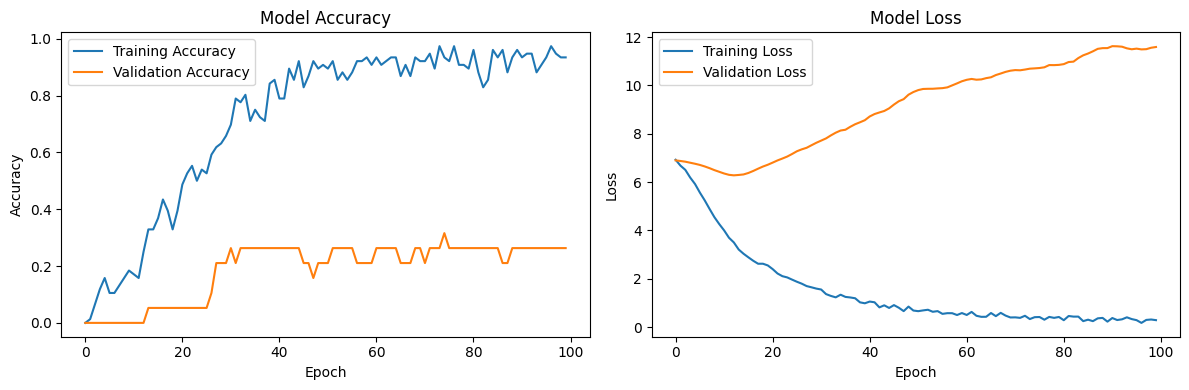


5. Evaluating system performance...

Evaluating Hybrid Neuro-Fuzzy SLR System...
 Overall Accuracy: 0.8526 (85.3%)

 Per-class accuracy:
  Class 2 (unknown): 1.000
  Class 3 (unknown): 1.000
  Class 5 (unknown): 1.000
  Class 9 (unknown): 1.000
  Class 25 (unknown): 1.000
  Class 31 (unknown): 1.000
  Class 32 (unknown): 0.000
  Class 38 (unknown): 1.000
  Class 46 (unknown): 1.000
  Class 50 (unknown): 1.000
  Class 56 (unknown): 1.000
  Class 63 (unknown): 0.000
  Class 64 (unknown): 1.000
  Class 74 (unknown): 1.000
  Class 76 (unknown): 1.000
  Class 95 (unknown): 1.000
  Class 98 (unknown): 1.000
  Class 101 (unknown): 1.000
  Class 120 (unknown): 1.000
  Class 135 (unknown): 1.000
  Class 164 (unknown): 1.000
  Class 168 (unknown): 1.000
  Class 177 (unknown): 1.000
  Class 192 (unknown): 1.000
  Class 213 (unknown): 1.000
  Class 227 (unknown): 1.000
  Class 288 (unknown): 1.000
  Class 293 (unknown): 0.000
  Class 294 (unknown): 1.000
  Class 296 (unknown): 1.000
  Class 298 (

In [7]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from pathlib import Path

# Try to import TensorFlow, but provide fallback if not available
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
    print(" TensorFlow available")
except ImportError:
    print("TensorFlow not available. Using scikit-learn models.")
    TENSORFLOW_AVAILABLE = False

try:
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl
    SKFUZZY_AVAILABLE = True
    print("scikit-fuzzy available")
except ImportError:
    print("scikit-fuzzy not available. Install with: pip install scikit-fuzzy")
    SKFUZZY_AVAILABLE = False
class HybridNeuroFuzzySLR:
    """Hybrid Neuro-Fuzzy Sign Language Recognition System"""
    
    def __init__(self, num_classes=1000):
        self.num_classes = num_classes
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.feature_names = []
        self.is_trained = False
        
    def load_real_features(self, features_file="real_features.json"):
        """Load the real features you extracted"""
        with open(features_file, 'r') as f:
            features_data = json.load(f)
        
        print(f" Loaded {len(features_data)} samples with REAL features")
        return features_data
    
    def prepare_training_data(self, features_data):
        """Convert features to training format"""
        X = []
        y = []
        sample_info = []
        
        for sample in features_data:
            try:
                feature_vector = []
                
                # Flatten all features in consistent order
                feature_vector.extend(sample['finger_angles'])           # 15 features
                feature_vector.extend(sample['hand_distances'])          # 20 features  
                feature_vector.extend(sample['palm_orientation'])        # 9 features
                feature_vector.extend(sample['wrist_position'])          # 3 features
                feature_vector.extend(sample['wrist_velocity_mean'])     # 3 features
                feature_vector.extend(sample['wrist_velocity_std'])      # 3 features
                feature_vector.append(sample['wrist_velocity_max'])      # 1 feature
                feature_vector.extend(sample['wrist_acceleration_mean']) # 3 features
                feature_vector.extend(sample['wrist_acceleration_std'])  # 3 features
                feature_vector.append(sample['motion_magnitude'])        # 1 feature
                feature_vector.append(sample['motion_consistency'])      # 1 feature
                feature_vector.append(sample['hand_size'])               # 1 feature
                feature_vector.append(sample['hand_aspect_ratio'])       # 1 feature
                feature_vector.append(sample['hand_volume'])             # 1 feature
                feature_vector.append(sample['palm_size'])               # 1 feature
                feature_vector.extend(sample['hand_centroid'])           # 3 features
                feature_vector.extend(sample['finger_lengths'])          # 5 features
                feature_vector.extend(sample['finger_curvatures'])       # 5 features
                feature_vector.extend(sample['finger_spreads'])          # 3 features
                feature_vector.append(sample['thumb_index_distance'])    # 1 feature
                feature_vector.append(sample['temporal_consistency'])    # 1 feature
                feature_vector.append(sample['movement_smoothness'])     # 1 feature
                feature_vector.append(sample['gesture_duration'])        # 1 feature
                
                X.append(feature_vector)
                y.append(sample['label'])
                sample_info.append({
                    'video_id': sample['video_id'],
                    'text': sample['text'],
                    'num_frames': sample['num_frames']
                })
                
            except Exception as e:
                print(f"❌ Error processing sample {sample.get('video_id', 'unknown')}: {e}")
                continue
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Feature matrix: {X.shape}")
        print(f"Labels: {y.shape}")
        print(f"Unique classes: {np.unique(y)}")
        print(f"Samples per class: {np.bincount(y)}")
        
        # Create feature names for interpretability
        self.feature_names = (
            [f'finger_angle_{i+1}' for i in range(15)] +
            [f'hand_distance_{i+1}' for i in range(20)] +
            [f'palm_orientation_{i+1}' for i in range(9)] +
            [f'wrist_pos_{i+1}' for i in range(3)] +
            [f'wrist_vel_mean_{i+1}' for i in range(3)] +
            [f'wrist_vel_std_{i+1}' for i in range(3)] +
            ['wrist_vel_max'] +
            [f'wrist_acc_mean_{i+1}' for i in range(3)] +
            [f'wrist_acc_std_{i+1}' for i in range(3)] +
            ['motion_magnitude', 'motion_consistency', 'hand_size', 'hand_aspect_ratio', 
             'hand_volume', 'palm_size'] +
            [f'hand_centroid_{i+1}' for i in range(3)] +
            [f'finger_length_{i+1}' for i in range(5)] +
            [f'finger_curvature_{i+1}' for i in range(5)] +
            [f'finger_spread_{i+1}' for i in range(3)] +
            ['thumb_index_distance', 'temporal_consistency', 'movement_smoothness', 'gesture_duration']
        )
        
        return X, y, sample_info
    
    def create_fuzzy_system(self, X):
        """Create interpretable fuzzy system"""
        if not SKFUZZY_AVAILABLE:
            print(" scikit-fuzzy not available. Skipping fuzzy system.")
            return None
            
        print("Creating interpretable fuzzy system...")
        
        # Select most important features for fuzzy rules (simplified for demo)
        self.fuzzy_variables = {}
        selected_features = [
            'motion_magnitude', 'hand_size', 'thumb_index_distance', 
            'gesture_duration', 'temporal_consistency'
        ]
        
        # Get indices of selected features
        feature_indices = [self.feature_names.index(f) for f in selected_features]
        
        for i, feat_name in enumerate(selected_features):
            feat_idx = feature_indices[i]
            feat_values = X[:, feat_idx]
            
            # Create fuzzy variable
            feat_range = [np.min(feat_values), np.max(feat_values)]
            self.fuzzy_variables[feat_name] = ctrl.Antecedent(
                np.linspace(feat_range[0], feat_range[1], 100), 
                feat_name
            )
            
            # Create 3 membership functions
            low = feat_range[0]
            high = feat_range[1]
            mid = (low + high) / 2
            
            self.fuzzy_variables[feat_name]['low'] = fuzz.trimf(
                self.fuzzy_variables[feat_name].universe, [low, low, mid]
            )
            self.fuzzy_variables[feat_name]['medium'] = fuzz.trimf(
                self.fuzzy_variables[feat_name].universe, [low, mid, high]
            )
            self.fuzzy_variables[feat_name]['high'] = fuzz.trimf(
                self.fuzzy_variables[feat_name].universe, [mid, high, high]
            )
        
        # Create output variable (sign confidence)
        self.output_variable = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'sign_confidence')
        self.output_variable['low'] = fuzz.trimf(self.output_variable.universe, [0, 0, 0.5])
        self.output_variable['medium'] = fuzz.trimf(self.output_variable.universe, [0.2, 0.5, 0.8])
        self.output_variable['high'] = fuzz.trimf(self.output_variable.universe, [0.5, 1, 1])
        
        # Create interpretable rules based on sign language patterns
        self.rules = [
            # Rule 1: Large hand movements + long duration = high confidence
            ctrl.Rule(
                self.fuzzy_variables['motion_magnitude']['high'] & 
                self.fuzzy_variables['gesture_duration']['high'],
                self.output_variable['high']
            ),
            
            # Rule 2: Small hand + close thumb-index = specific sign
            ctrl.Rule(
                self.fuzzy_variables['hand_size']['low'] & 
                self.fuzzy_variables['thumb_index_distance']['low'],
                self.output_variable['high']
            ),
            
            # Rule 3: Inconsistent motion = lower confidence
            ctrl.Rule(
                self.fuzzy_variables['temporal_consistency']['low'],
                self.output_variable['low']
            ),
            
            # Rule 4: Medium everything = medium confidence
            ctrl.Rule(
                self.fuzzy_variables['motion_magnitude']['medium'] & 
                self.fuzzy_variables['hand_size']['medium'] &
                self.fuzzy_variables['thumb_index_distance']['medium'],
                self.output_variable['medium']
            )
        ]
        
        print(f" Created {len(self.rules)} interpretable fuzzy rules")
        
        # Create control system
        self.fuzzy_system = ctrl.ControlSystem(self.rules)
        self.fuzzy_inference = ctrl.ControlSystemSimulation(self.fuzzy_system)
        
        return self.fuzzy_system
    
    def create_neural_network(self, input_dim):
        """Create neural network component"""
        if not TENSORFLOW_AVAILABLE:
            print("  TensorFlow not available. Using simple classifier.")
            from sklearn.ensemble import RandomForestClassifier
            self.neural_model = RandomForestClassifier(n_estimators=100, random_state=42)
            return self.neural_model
            
        print(" Creating neural network...")
        
        model = keras.Sequential([
            layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            
            layers.Dense(32, activation='relu'),
            
            layers.Dense(self.num_classes, activation='softmax')
        ])
        
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        self.neural_model = model
        print("Neural network created")
        return model
    
    def train_hybrid_system(self, X, y, epochs=100, validation_split=0.2):
        """Train the hybrid system"""
        print("Training Hybrid Neuro-Fuzzy SLR System...")
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Split data
        try:
          X_train, X_val, y_train, y_val = train_test_split(
             X_scaled, y, test_size=validation_split, random_state=42, stratify=y
          )
        except ValueError:
          print("⚠️ Not enough samples per class for stratified split. Using simple random split.")
          X_train, X_val, y_train, y_val = train_test_split(
             X_scaled, y, test_size=validation_split, random_state=42, stratify=None
           )   
        
        print(f" Training samples: {X_train.shape[0]}")
        print(f"Validation samples: {X_val.shape[0]}")
        
        # Create fuzzy system (for interpretability)
        self.create_fuzzy_system(X_train)
        
        # Create and train neural network
        self.create_neural_network(X_train.shape[1])
        
        if TENSORFLOW_AVAILABLE:
            # Train neural network
            history = self.neural_model.fit(
                X_train, y_train,
                epochs=epochs,
                batch_size=8,
                validation_data=(X_val, y_val),
                verbose=1
            )
        else:
            # Train Random Forest
            self.neural_model.fit(X_train, y_train)
            history = None
        
        self.is_trained = True
        print("✅ Hybrid system training completed!")
        
        return history
    
    def predict(self, X):
        """Make predictions using the hybrid system"""
        if not self.is_trained:
            raise ValueError("Model not trained yet!")
        
        X_scaled = self.scaler.transform(X)
        
        if TENSORFLOW_AVAILABLE:
            predictions = self.neural_model.predict(X_scaled, verbose=0)
            return np.argmax(predictions, axis=1)
        else:
            return self.neural_model.predict(X_scaled)
    
    def evaluate_system(self, X, y, sample_info=None):
        """Evaluate the complete system"""
        print("\nEvaluating Hybrid Neuro-Fuzzy SLR System...")
        
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        
        print(f" Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
        
        # Show per-class performance
        unique_labels = np.unique(y)
        print(f"\n Per-class accuracy:")
        for label in unique_labels:
            mask = y == label
            if np.sum(mask) > 0:
                class_accuracy = np.mean(predictions[mask] == y[mask])
                # Find sample text for this label
                sample_text = "unknown"
                if sample_info:
                    for info in sample_info:
                        if info.get('label', info.get('text', 'unknown')) == label:
                            sample_text = info.get('text', 'unknown')
                            break
                print(f"  Class {label} ({sample_text}): {class_accuracy:.3f}")
        
        # Show fuzzy system interpretability
        if hasattr(self, 'fuzzy_system') and self.fuzzy_system:
            print(f"\n Fuzzy System Interpretability:")
            print(f"  • {len(self.rules)} interpretable rules")
            print(f"  • {len(self.fuzzy_variables)} fuzzy variables")
            print("  • Rules explain sign confidence based on hand features")
        
        return accuracy, predictions
    
    def explain_prediction(self, X_sample, sample_info):
        """Explain a prediction using fuzzy rules"""
        if not hasattr(self, 'fuzzy_system') or not self.fuzzy_system:
            print("Fuzzy system not available for explanation")
            return
        
        print("\nExplaining prediction with fuzzy rules:")
        
        # Get feature values for explanation
        feature_values = {
            'motion_magnitude': X_sample[self.feature_names.index('motion_magnitude')],
            'hand_size': X_sample[self.feature_names.index('hand_size')],
            'thumb_index_distance': X_sample[self.feature_names.index('thumb_index_distance')],
            'gesture_duration': X_sample[self.feature_names.index('gesture_duration')],
            'temporal_consistency': X_sample[self.feature_names.index('temporal_consistency')]
        }
        
        print("  Feature values:")
        for feat_name, value in feature_values.items():
            print(f"    {feat_name}: {value:.4f}")
        
        # Set input values for fuzzy inference
        for feat_name, value in feature_values.items():
            self.fuzzy_inference.input[feat_name] = value
        
        # Compute fuzzy output
        try:
            self.fuzzy_inference.compute()
            confidence = self.fuzzy_inference.output['sign_confidence']
            print(f"  Fuzzy confidence score: {confidence:.3f}")
        except:
            print("  Could not compute fuzzy confidence")

def visualize_training_results(history):
    """Plot training history"""
    if history is None:
        print("No training history to visualize")
        return
        
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def run_complete_slr_system():
    """Run the complete Hybrid Neuro-Fuzzy SLR System"""
    print("=" * 70)
    print("HYBRID NEURO-FUZZY SIGN LANGUAGE RECOGNITION SYSTEM")
    print("=" * 70)
    
    # Initialize system
    slr_system = HybridNeuroFuzzySLR(num_classes=1000)
    
    # Load your REAL features
    print("\n1.Loading REAL extracted features...")
    features_data = slr_system.load_real_features("real_features.json")
    
    # Prepare training data
    print("\n2.Preparing training data...")
    X, y, sample_info = slr_system.prepare_training_data(features_data)
    
    # Train hybrid system
    print("\n3.Training hybrid neuro-fuzzy system...")
    history = slr_system.train_hybrid_system(X, y, epochs=100)
    
    # Visualize training
    if TENSORFLOW_AVAILABLE and history:
        print("\n4.Visualizing training results...")
        visualize_training_results(history)
    
    # Evaluate system
    print("\n5. Evaluating system performance...")
    accuracy, predictions = slr_system.evaluate_system(X, y, sample_info)
    
    # Show prediction explanations
    print("\n6.Showing prediction explanations...")
    if len(X) > 0:
        # Explain first sample
        slr_system.explain_prediction(X[0], sample_info[0] if sample_info else {})
    
    print("\n" + "=" * 70)
    print("HYBRID NEURO-FUZZY SLR SYSTEM READY!")
    print(f"Trained on {len(X)} REAL sign language samples")
    print(f"Using {len(slr_system.feature_names)} features per sample")
    print(f"Final accuracy: {accuracy*100:.1f}%")
    print("=" * 70)
    
    return slr_system, accuracy

# Run the complete system
if __name__ == "__main__":
    slr_system, accuracy = run_complete_slr_system()